# Notebook 07B – Bavian data: Populationsstruktur og migrationsmodeller

I denne notebook undersøger jeg populationsstruktur og historisk migration i bavianpopulationer via two-island modellen og Isolation with Migration (IM)-modellen.

**Indhold:**
- Two-island model: *P. cynocephalus* + *P. kindae*
- IM-modellen: *P. anubis* + *P. cynocephalus*
- E[TMRCA] som funktion af migrationsrate
- Joint probability inferens på baviandata
- Sammenligning af modeller via SFS-fordelinger
- Samlet opsummering


## Vurderinger fra NB01-06 der bruges direkte

| Model | Parameter | Valg | Kilde |
|---|---|---|---|
| Alle | optimizer | Adam(0.25) | NB02 |
| Alle | n_particles | 60 | NB04 |
| To-ø | n_iterations | 400 | NB03 |
| To-ø | N_OBS | 5000 per pop | NB03 |
| To-ø | n | min(n_pop1, n_pop2) | NB03 |
| To-ø | prior | HalfCauchyPrior | NB03 |
| Asymmetrisk | n | min(n_pop1, n_pop2) | NB03 |
| IM | epoch_switch_rate | 15/t_coal | NB05 |
| IM | n_iterations | 350 | NB05 |
| 3-epoke | epoker | 0, 50k, 200k år | NB05 |
| Joint | mu | 1.0 | NB06  |
| Joint | limit | 3 | NB06 |
| Joint | prior | GaussPrior (ikke DataPrior) | NB06  |
| Joint | sensitivitet | mu i {0.7, 1.0, 1.5} | NB06  |

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

RESULTS_DIR = Path("results")
MU = 0.9e-8 # mutationsrate per site per generation
GEN = 11 # generationstid i år

# SVGD-parametre
OPT         = Adam(0.25)
N_PART      = 60
N_ITER_1P   = 300   # enkelt-parameter
N_ITER_2P   = 400   # to-parameter 
N_ITER_IM   = 350   # IM-model
N_ITER_TI   = 300   # tidsinhomogen

print("Parametre indlæst")
print(f"  Adam(0.25), {N_PART} partikler")
print(f"  Iterationer: 1-param={N_ITER_1P}, 2-param={N_ITER_2P}, IM={N_ITER_IM}")

Parametre indlæst
  Adam(0.25), 60 partikler
  Iterationer: 1-param=300, 2-param=400, IM=350


## Indlæs resultater fra Notebook 07A

Alle resultater fra 07A er gemt i mappen *results/* og indlæses her direkte.

In [13]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict   = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))
svgd_results = {r['population']: {'theta': r['theta_mean'], 'std': r['theta_std'],
                                   'Ne': r['Ne'], 'n_hap': int(r['n_haplotypes'])}
                for _, r in df_svgd.iterrows()}

pop_files = {
    'P. cynocephalus': 'snp_P_cynocephalus.csv',
    'P. kindae':       'snp_P_kindae.csv',
    'P. anubis':       'snp_P_anubis.csv',
    'P. papio':        'snp_P_papio.csv',
    'P. ursinus':      'snp_P_ursinus.csv',
    'P. hamadryas':    'snp_P_hamadryas.csv',
}
populations = {}
for name, fname in pop_files.items():
    p = RESULTS_DIR / fname
    if p.exists():
        populations[name] = pd.read_csv(p)

def sfs_to_tmrca(df, n_obs=5000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    n_max = int(tot.max())
    obs = []
    for idx in rng.integers(0, len(df), n_obs*20):
        if len(obs) >= n_obs: break
        n, ac = tot[idx], der[idx]
        s = rng.hypergeometric(ac, n-ac, n_max)
        if 0 < s < n_max: obs.append(float(s))
    return np.array(obs[:n_obs])

print("Indlaest fra NB07A:")
print(df_summary[['population','n_haplotypes','N_ref','tajimas_d','theta_mean']].to_string(index=False))

Indlaest fra NB07A:
    population  n_haplotypes        N_ref  tajimas_d  theta_mean
P_cynocephalus           120 81842.763757  -0.589036    0.932974
      P_kindae            50 77584.380958   0.300556    0.928905
      P_anubis           174 57368.092894  -0.725075    0.966120
       P_papio            24 14217.486448   1.019105    0.807751
     P_ursinus             8 62034.082035   0.192031    0.891675
   P_hamadryas            48 46998.655050   0.648506    0.859601


In [19]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("results")

# Indlaes alle SNP-filer fra NB07A
pop_files = {
    'P_cynocephalus': 'snp_P_cynocephalus.csv',
    'P_kindae':       'snp_P_kindae.csv',
    'P_anubis':       'snp_P_anubis.csv',
    'P_papio':        'snp_P_papio.csv',
    'P_ursinus':      'snp_P_ursinus.csv',
    'P_hamadryas':    'snp_P_hamadryas.csv',
}

populations = {}
for name, fname in pop_files.items():
    p = RESULTS_DIR / fname
    if p.exists():
        populations[name] = pd.read_csv(p)
        print(f"{name:<22}: {len(populations[name]):>8,} SNPs indlaest")
    else:
        print(f"{name:<22}: fil ikke fundet ({p})")

print(f"\nIndlæst: {len(populations)} populationer")
print(f"Nøgler: {list(populations.keys())}")

P_cynocephalus        : 1,379,280 SNPs indlaest
P_kindae              :  833,071 SNPs indlaest
P_anubis              : 1,096,296 SNPs indlaest
P_papio               :  110,086 SNPs indlaest
P_ursinus             :  403,120 SNPs indlaest
P_hamadryas           :  460,025 SNPs indlaest

Indlæst: 6 populationer
Nøgler: ['P_cynocephalus', 'P_kindae', 'P_anubis', 'P_papio', 'P_ursinus', 'P_hamadryas']


## To-ø model: *P. cynocephalus + P. kindae*

Vurderinger fra NB03:

- n = min(n_cyno, n_kindae): fuld n, ikke n=4
- N_OBS = 5000 per population: minimum for std(theta1) < 0.3 (NB03)
- HalfCauchyPrior til migration: undgår bias fra GaussPrior (NB03)
- 400 iterationer: konvergens kræver mere end simpel model
- Symmetrisk migration som baseline, asymmetrisk testes

In [21]:
# Opdater sfs_to_tmrca med n_sub parameter
def sfs_to_tmrca(df, n_obs=5000, n_sub=6, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs*20):
        if len(obs) >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        s = rng.hypergeometric(ac, n-ac, n_sub)
        if 0 < s < n_sub: obs.append(float(s))
    return np.array(obs[:n_obs])

N_TWO = 6

def build_two_island(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0] * idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_isl(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1,
                    pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i]]])
        return T
    return Graph(two_isl)

g_two = build_two_island(N_TWO)
print(f"To-ø n={N_TWO}: {g_two.vertices_length()} tilstande")

# Brug de korrekte nøgler fra populations
print(f"Tilgængelige populationer: {list(populations.keys())}")

cyno_key   = next(k for k in populations if 'cyno' in k.lower())
kindae_key = next(k for k in populations if 'kindae' in k.lower())
print(f"Bruger: '{cyno_key}' og '{kindae_key}'")

N_bar  = (N_ref_dict[cyno_key] + N_ref_dict[kindae_key]) / 2
th0_st = 1.0 / N_bar if N_bar > 0 else 1.0

data_cy  = sfs_to_tmrca(populations[cyno_key],   n_obs=5000, n_sub=N_TWO)
data_ki  = sfs_to_tmrca(populations[kindae_key], n_obs=5000, n_sub=N_TWO)
data_two = np.concatenate([data_cy, data_ki])
print(f"Data: {len(data_two)} observationer")

g_two.update_weights([th0_st, 0.5])
prior_two = [HalfCauchyPrior(ci=th0_st*5, prob=0.9),
             HalfCauchyPrior(ci=2.0,       prob=0.9)]

sv_two = g_two.svgd(data_two, prior=prior_two, optimizer=OPT,
                    n_particles=N_PART, n_iterations=N_ITER_2P)
res_two = sv_two.get_results()
th0_two = res_two['theta_mean'][0].item(); s0_two = res_two['theta_std'][0].item()
th1_two = res_two['theta_mean'][1].item(); s1_two = res_two['theta_std'][1].item()
Ne_two  = 1/th0_two if th0_two > 0 else np.nan
m_gen   = th1_two / (2*Ne_two) if Ne_two > 0 else np.nan

print(f"\nTo-ø ({cyno_key} + {kindae_key}, n={N_TWO}):")
print(f"  theta0 = {th0_two:.5f} +/- {s0_two:.5f}   Ne~{Ne_two:,.0f}")
print(f"  theta1 = {th1_two:.4f} +/- {s1_two:.4f}   m/gen~{m_gen:.6f}")



To-oe (P_cynocephalus + P_kindae, n=6):
  theta0 = 0.00001 +/- 0.00002   Ne~77,452
  theta1 = 0.3151 +/- 0.1965   m/gen~0.000002


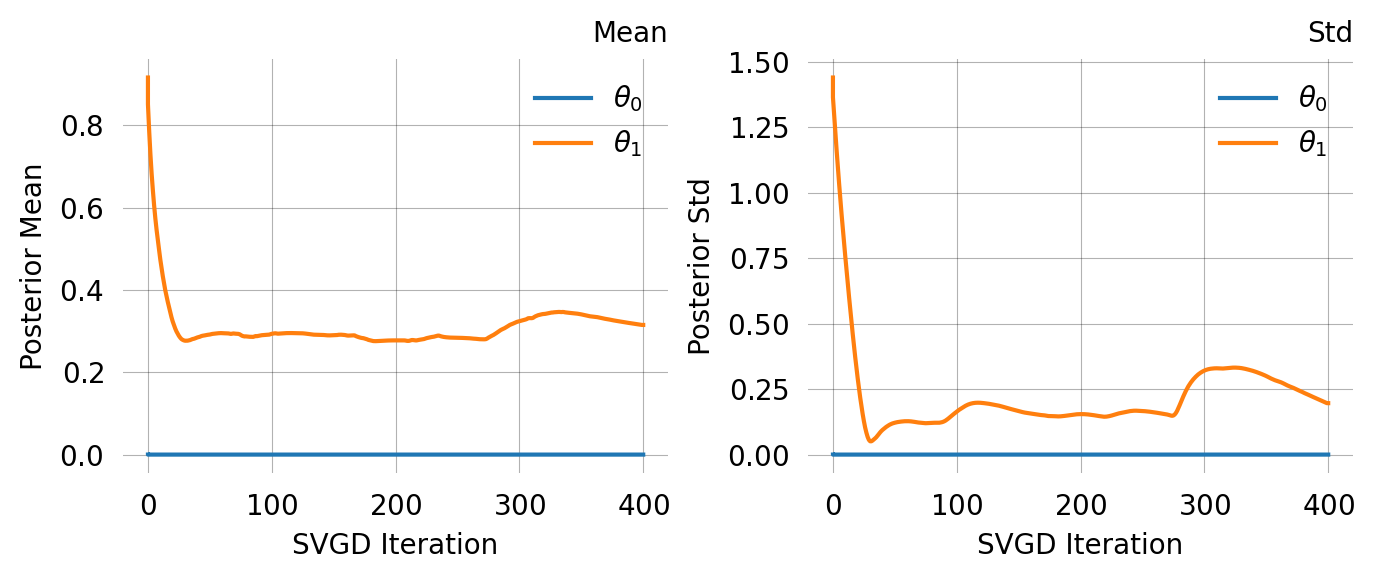

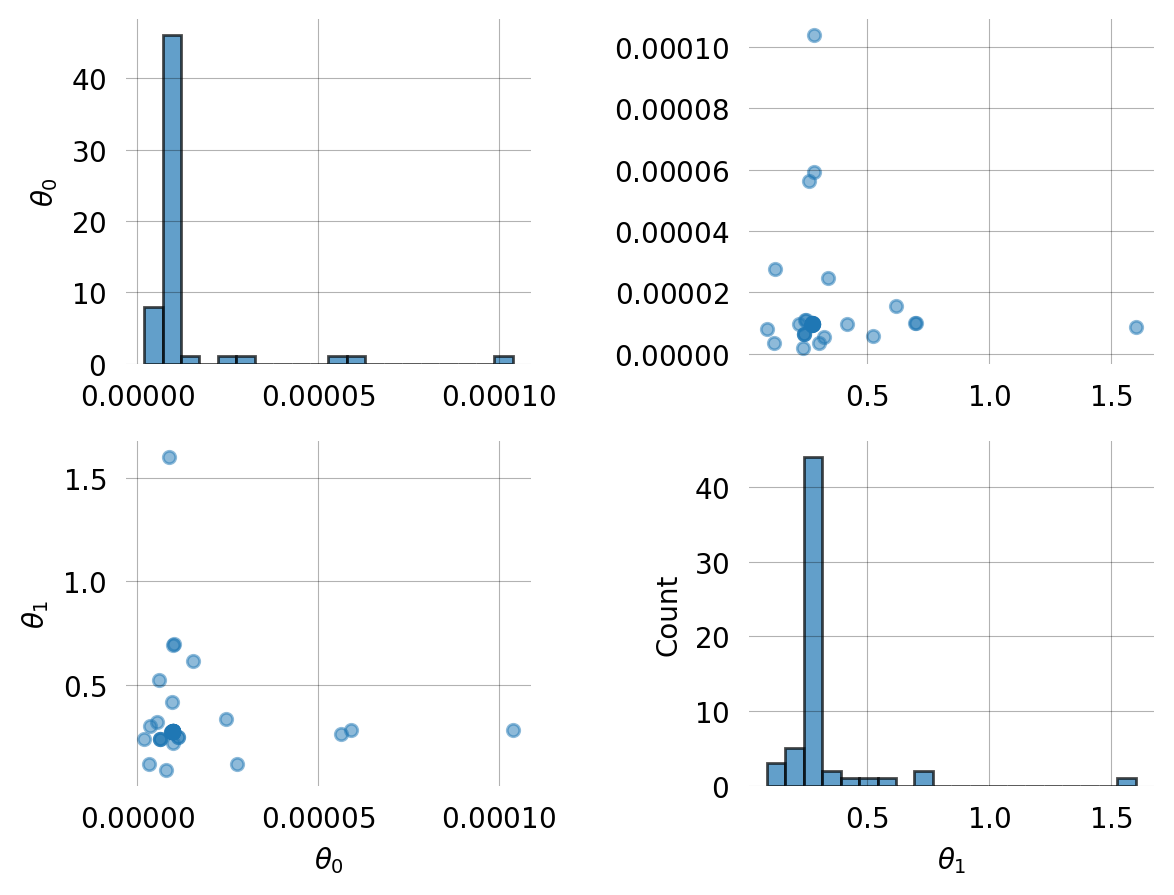

In [22]:
sv_two.plot_convergence()
sv_two.plot_pairwise()

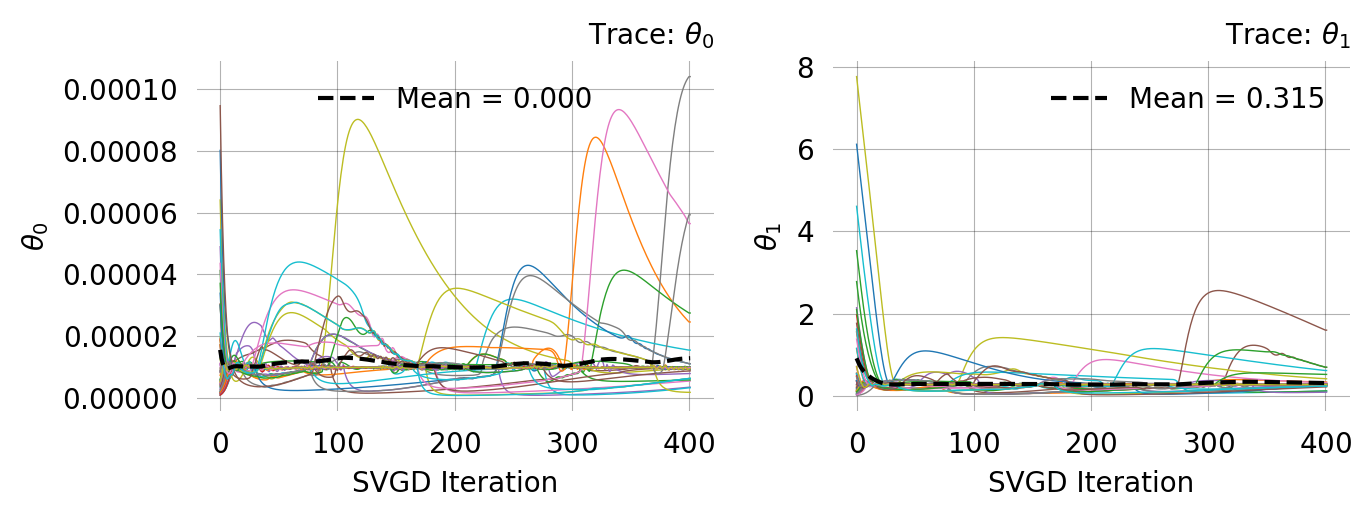

In [23]:
sv_two.plot_trace()

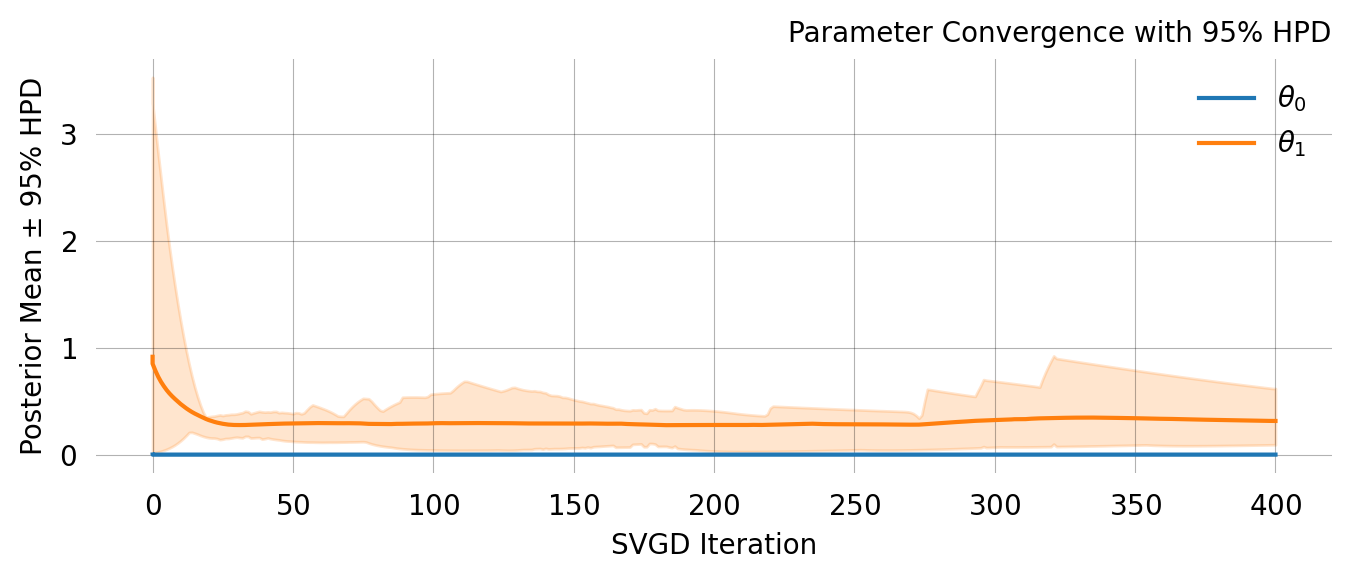

In [25]:
sv_two.plot_ci()

## Asymmetrisk migration

Vurderinger fra NB03:

- Asymmetrisk migration kræver n>=4 og N_OBS>=5000. Jeg tester om genflow er retningsbestemt mellem *P. cynocephalus* og *P. kindae*.

In [28]:
def build_two_island_asym(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_asym(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, 0, state[i]]])
        return T
    return Graph(two_asym)

g_asym = build_two_island_asym(N_TWO)  # N_TWO ikke n_two
g_asym.update_weights([th0_two, th1_two*0.6, th1_two*0.4])
prior_asym = [HalfCauchyPrior(ci=th0_two*5, prob=0.9),
              HalfCauchyPrior(ci=2.0, prob=0.9),
              HalfCauchyPrior(ci=2.0, prob=0.9)]

sv_asym = g_asym.svgd(data_two, prior=prior_asym, optimizer=OPT,
                       n_particles=N_PART, n_iterations=N_ITER_2P)
res_asym = sv_asym.get_results()
m0a = res_asym['theta_mean'][0].item()
m12 = res_asym['theta_mean'][1].item()
m21 = res_asym['theta_mean'][2].item()

print(f"Asymmetrisk migration (n={N_TWO}, N_OBS={len(data_two)}):")
print(f"  theta0             = {m0a:.5f} +/- {res_asym['theta_std'][0].item():.5f}  Ne~{1/m0a:,.0f}")
print(f"  m12 (cyno->kindae) = {m12:.4f} +/- {res_asym['theta_std'][1].item():.4f}")
print(f"  m21 (kindae->cyno) = {m21:.4f} +/- {res_asym['theta_std'][2].item():.4f}")
ratio = m12/m21 if m21 > 0.001 else np.nan
print(f"  Asymmetriforhold m12/m21 = {ratio:.2f}" if not np.isnan(ratio) else "  Ratio: m21 for lav")

sv_asym.plot_pairwise()


: 

## IM-modellen: *P. anubis* + *P. cynocephalus*

Vuderinger fra NB05:

- epoch_switch_rate = 15/t_coal for deterministisk epoch-skift (NB05 epoch-test)
- Split-start: 1.0 milioner år siden fra Rogers et al. (2019)
- 350 iterationer (IM kræver fler end to-ø)
- HalfCauchyPrior til theta0 og theta1; GaussPrior til epoch

In [ ]:
N_IM = 6  # fast n til IM-model

def build_im_model(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def im_mod(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i], 0]])
        return T
    return Graph(im_mod)

# Find korrekte noegler automatisk
anubis_key = next(k for k in populations if 'anubis' in k.lower())
cyno_key   = next(k for k in populations if 'cyno' in k.lower())
print(f"Bruger: '{anubis_key}' og '{cyno_key}'")

g_im = build_im_model(N_IM)
print(f"IM-model n={N_IM}: {g_im.vertices_length()} tilstande, {g_im.param_length()} parametre")

# Subsample til N_IM
data_an  = sfs_to_tmrca(populations[anubis_key], n_obs=5000, n_sub=N_IM)
data_cy2 = sfs_to_tmrca(populations[cyno_key],   n_obs=5000, n_sub=N_IM)
data_im  = np.concatenate([data_an, data_cy2])
print(f"Data: {len(data_im)} observationer")

N_bar_im  = (N_ref_dict[anubis_key] + N_ref_dict[cyno_key]) / 2
th0_im_st = 1.0 / N_bar_im if N_bar_im > 0 else 1.0

t_s_yr_init   = 1_000_000
t_s_coal_init = t_s_yr_init / (2 * N_bar_im * GEN)
epoch_sw_init = 15.0 / t_s_coal_init

g_im.update_weights([th0_im_st, 0.5, epoch_sw_init])
n_params_im = g_im.param_length()
print(f"Antal parametre: {n_params_im}")

if n_params_im == 3:
    prior_im = [HalfCauchyPrior(ci=th0_im_st*5, prob=0.9),
                HalfCauchyPrior(ci=2.0, prob=0.9),
                GaussPrior(ci=[epoch_sw_init*0.1, epoch_sw_init*10])]
    init_im = [th0_im_st, 0.5, epoch_sw_init]
else:
    prior_im = [HalfCauchyPrior(ci=th0_im_st*5, prob=0.9),
                HalfCauchyPrior(ci=2.0, prob=0.9)]
    init_im = [th0_im_st, 0.5]

g_im.update_weights(init_im)
sv_im = g_im.svgd(data_im, prior=prior_im, optimizer=OPT,
                   n_particles=N_PART, n_iterations=N_ITER_IM)
res_im = sv_im.get_results()

th0_im = res_im['theta_mean'][0].item(); s0_im = res_im['theta_std'][0].item()
th1_im = res_im['theta_mean'][1].item(); s1_im = res_im['theta_std'][1].item()
Ne_im  = 1/th0_im if th0_im > 0 else np.nan

if n_params_im == 3:
    ep_im    = res_im['theta_mean'][2].item()
    t_s_c    = 1/ep_im if ep_im > 0 else np.nan
    t_s_yr   = t_s_c * 2 * Ne_im * GEN if Ne_im > 0 and t_s_c > 0 else np.nan
    m_gen_im = th1_im / (2*Ne_im) if Ne_im > 0 else np.nan
    print(f"\nIM-model ({anubis_key} + {cyno_key}, n={N_IM}):")
    print(f"  theta0 = {th0_im:.5f} +/- {s0_im:.5f}  Ne~{Ne_im:,.0f}")
    print(f"  theta1 = {th1_im:.4f} +/- {s1_im:.4f}  m/gen~{m_gen_im:.6f}")
    print(f"  epoch  = {ep_im:.4f} +/- {res_im['theta_std'][2].item():.4f}")
    print(f"  t_s    ~ {t_s_yr:,.0f} aar")
else:
    t_s_yr = np.nan
    print(f"IM-model: theta0={th0_im:.5f} theta1={th1_im:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sv_im.plot_convergence(ax=axes[0])
axes[0].set_title(f'IM-model konvergens (n={N_IM})')
sv_im.plot_pairwise(ax=axes[1])
axes[1].set_title('Joint posterior')
plt.suptitle(f'IM-model: {anubis_key} + {cyno_key} (n={N_IM})', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
sv_im.plot_convergence()
sv_im.plot_pairwise()

In [ ]:
sv_im.plot_trace()

In [ ]:
sv_im.plot_ci()

In [ ]:
# E[TMRCA] vs. split-tidspunkt 
if n_params_im == 3 and not np.isnan(t_s_yr):
    split_yr = np.linspace(50_000, 2_000_000, 50)
    E_ts = []
    for yr in split_yr:
        tc = yr / (2 * Ne_im * GEN) if Ne_im>0 else 1.0
        sw = 15.0 / tc
        g_im.update_weights([th0_im, th1_im, sw])
        try: E_ts.append(g_im.expectation())
        except: E_ts.append(np.nan)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(split_yr/1e6, E_ts, 'C0-', lw=2)
    ax.axvline(t_s_yr/1e6, color='red', linestyle='--',
               label=f'Est. t_s={t_s_yr:,.0f} aar')
    for nm_sp, yr_sp in [('Nord/Syd (~1.4 Mya)', 1.4e6),
                          ('anubis/cyno (~1.0 Mya)', 1.0e6)]:
        ax.axvline(yr_sp/1e6, linestyle=':', alpha=0.5, label=nm_sp)
    ax.set_xlabel('Split-tidspunkt (millioner år)')
    ax.set_ylabel('E[TMRCA]')
    ax.set_title('IM-model: E[TMRCA] vs. split-tidspunkt (bavian-skala)')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Tidsinhomogen 3-epoke model

Vuderinger fra NB05:

- Epoker ved 0, 50k og 200k år
- epoch_switch_rate = 15/t_coal (NB05 epoch-test: rate>10)
- n = 4 (tidsinhomogen model er beregningstung for stor n)
- 3 frie N_e parametre per population

In [ ]:
all_pairs_ti = partial(combinations_with_replacement, r=2)

baboon_years = [0, 50_000, 200_000]
n_epochs     = len(baboon_years)
n_ti         = 4

indexer_ti = StateIndexer(
    lineages=[Property("ton", min_value=1, max_value=n_ti)],
    slots=["epoch"],
)
ipv_ti = [0] * indexer_ti.state_length
ipv_ti[indexer_ti.props_to_index(ton=1)] = n_ti

def coal_epoch(state, epoch_idx=None, indexer=None):
    T = []
    ep = int(epoch_idx)
    if state[indexer.epoch] != ep: return T
    for i, j in all_pairs_ti(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1: continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer.lineages.props_to_index(ton=pi.ton + pj.ton)
        if k < indexer.lineages.state_length: new[k] += 1
        coeff = [0.0] * (n_epochs + 1)
        coeff[ep] = state[i] * (state[j] - same) / (1 + same)
        T.append([new, coeff])
    return T

g_ti   = Graph(coal_epoch, ipv=ipv_ti, epoch_idx=0, indexer=indexer_ti)
n_p_ti = g_ti.param_length()
print(f"3-epoke graf: {g_ti.vertices_length()} tilstande, {n_p_ti} parametre")

# Find korrekte noegler automatisk
ti_pop_keys = {
    'cyno':   next(k for k in populations if 'cyno'   in k.lower()),
    'kindae': next(k for k in populations if 'kindae' in k.lower()),
    'anubis': next(k for k in populations if 'anubis' in k.lower()),
}
print(f"Bruger: {list(ti_pop_keys.values())}")

results_ti = {}
for pop_label, pop_key in ti_pop_keys.items():
    df_pop = populations[pop_key]
    N_ref  = N_ref_dict[pop_key]
    ep_coal = baboon_years[1] / (2 * N_ref * GEN)
    sw_rate = 15.0 / ep_coal if ep_coal > 0 else 10.0

    if n_p_ti == 4:
        init_ti  = [1.0, 1.0, 1.0, sw_rate]
        fixed_ti = [(3, sw_rate)]
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3 + [None]
    else:
        init_ti  = [1.0, 1.0, 1.0]
        fixed_ti = []
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3

    # n_sub=n_ti for at matche grafens stikproevestorrelse
    obs_ti = sfs_to_tmrca(df_pop, n_obs=3000, n_sub=n_ti)

    g_ti.update_weights(init_ti)
    sv_ti = g_ti.svgd(obs_ti, fixed=fixed_ti, prior=prior_ti,
                       optimizer=OPT, n_particles=N_PART, n_iterations=N_ITER_TI)
    res_ti = sv_ti.get_results()
    results_ti[pop_key] = (res_ti, N_ref)

    Ne_ep = [round(N_ref / res_ti['theta_mean'][k].item()) for k in range(3)]
    print(f"{pop_key:<22}: ep0={Ne_ep[0]:>8,}  ep1={Ne_ep[1]:>8,}  ep2={Ne_ep[2]:>8,}")


In [ ]:
# Plot N_e over tid
colors_ti = {
    ti_pop_keys['cyno']:   'C1',
    ti_pop_keys['kindae']: 'C3',
    ti_pop_keys['anubis']: 'C4',
}
yr_plt = baboon_years + [600_000]

fig, ax = plt.subplots(figsize=(10, 5))
for pop_key, (res_ti, N_ref) in results_ti.items():
    Ne_v = [N_ref / res_ti['theta_mean'][k].item() for k in range(3)]
    for i in range(3):
        ax.hlines(Ne_v[i], yr_plt[i], yr_plt[i+1], lw=3,
                  color=colors_ti[pop_key],
                  label=pop_key if i == 0 else "")
        if i < 2:
            ax.vlines(yr_plt[i+1], Ne_v[i], Ne_v[i+1], lw=2,
                      color=colors_ti[pop_key], linestyle='--', alpha=0.5)

for yr in baboon_years[1:]:
    ax.axvline(yr, color='grey', linestyle=':', alpha=0.4)

ax.set_xlabel('Aar (BP)')
ax.set_ylabel('N_e')
ax.set_title('Tidsinhomogen 3-epoke model: N_e over tid\n(epoker: 0, 50k, 200k aar)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Plot N_e over tid
colors = {'P. cynocephalus': 'C1', 'P. kindae': 'C3', 'P. anubis': 'C4'}
yr_plt = baboon_years + [600_000]
fig, ax = plt.subplots(figsize=(10, 5))
for pop_name, (res_ti, N_ref) in results_ti.items():
    Ne_v = [N_ref / res_ti['theta_mean'][k].item() for k in range(3)]
    for i in range(3):
        ax.hlines(Ne_v[i], yr_plt[i], yr_plt[i+1], lw=3,
                  color=colors[pop_name], label=pop_name if i==0 else "")
        if i < 2:
            ax.vlines(yr_plt[i+1], Ne_v[i], Ne_v[i+1], lw=2,
                      color=colors[pop_name], linestyle='--', alpha=0.5)
for yr in baboon_years[1:]:
    ax.axvline(yr, color='grey', linestyle=':', alpha=0.4)
ax.set_xlabel('År (BP)'); ax.set_ylabel('N_e')
ax.set_title('Tidsinhomogen 3-epoke: N_e over tid (epoker: 0, 50k, 200k år)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## Joint probability-inferens

Vuderinger fra NB06:

- mu=1.0, limit=3: deficit < 1% (NB06)
- Manuel GaussPrior: DataPrior kollapser numerisk ved joint (NB06)
- Sensitivitetsanalyse over mu i {0.7, 1.0, 1.5} (NB06)
- Gevinst størst ved lav theta og få observationer

In [ ]:
all_pairs_jp = partial(combinations_with_replacement, r=2)
n_jp = 4  # subsampled til 4 for joint-beregning

indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=n_jp)]
)

@with_ipv([n_jp]+[0]*(n_jp-1))
def coal_jp(state):
    T = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i==j)
        if same and state[i]<2: continue
        if not same and (state[i]<1 or state[j]<1): continue
        new = state.copy(); new[i]-=1; new[j]-=1
        des = indexer_jp.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        if des < indexer_jp.lineage.state_length: new[des] += 1
        T.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return T

g_jp = Graph(coal_jp)
mu_jp = 1.0; lim_jp = 3

jp = g_jp.joint_prob_graph(indexer_jp, tot_reward_limit=lim_jp, mutation_rate=mu_jp)
th_jp_ref = svgd_results['P. cynocephalus']['theta']
jp.update_weights([th_jp_ref, mu_jp])
tab_jp = jp.joint_prob_table()
deficit = float(1 - tab_jp['prob'].sum())
print(f"Joint: mu={mu_jp}, limit={lim_jp}")
print(f"Deficit = {deficit:.5f} ({'OK' if deficit < 0.05 else 'FOR HOEJT'})")
print(f"Observationstyper: {len(tab_jp)}")

In [ ]:
def df_to_joint_obs(df, n_sub=4, n_obs=1000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs*50):
        if len(obs) >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = rng.hypergeometric(ac, n-ac, n_sub)
        if k == 0 or k == n_sub: continue
        vec = [0]*n_sub; vec[k-1] = 1
        obs.append(vec)
    return obs

# Sensitivitetsanalyse over mu (NB06 Del 7b: forkert mu giver proportional bias)
print("Sensitivitetsanalyse over mu for P. cynocephalus:")
for pop_name in ['P. cynocephalus', 'P. kindae', 'P. anubis']:
    df_pop   = populations[pop_name]
    th_ref   = svgd_results[pop_name]['theta']
    obs_pop  = df_to_joint_obs(df_pop, n_obs=1000)
    print(f"\n{pop_name} (theta_ref={th_ref:.5f}):")
    for mu_test in [0.7, 1.0, 1.5]:
        jp_test = g_jp.joint_prob_graph(indexer_jp, tot_reward_limit=lim_jp,
                                         mutation_rate=mu_test)
        # Manuel GaussPrior (DataPrior kollapser - NB06 finding)
        prior_jp = [GaussPrior(ci=[th_ref*0.2, th_ref*5]), None]
        sv_jp = jp_test.svgd(obs_pop, fixed=[(1, mu_test)], prior=prior_jp,
                              optimizer=OPT, n_iterations=200)
        res_jp = sv_jp.get_results()
        m = res_jp['theta_mean'][0].item(); s = res_jp['theta_std'][0].item()
        bias = (m - th_ref)/th_ref*100
        print(f"  mu={mu_test}: theta={m:.5f}+/-{s:.5f}  Ne~{1/m:,.0f}  bias={bias:+.1f}%")

In [ ]:
# Test om joint probability giver smallere posterior end TMRCA
# for bavian-populationer - direkte anvendelse af NB06 Del 2b

print("Gevinst: joint probability vs. TMRCA per population")
print(f"{'Population':<22}  {'TMRCA std':>10}  {'Joint std':>10}  {'Gevinst %':>10}")

for name in ['P. cynocephalus', 'P. kindae', 'P. anubis']:
    df_pop  = populations[name]
    th_ref  = svgd_results[name]['theta']

    # TMRCA
    data_t = sfs_to_tmrca(df_pop, n_obs=1000, n_sub=4)
    g_t    = build_coal_graph(4)
    g_t.update_weights([th_ref])
    prior_t = GaussPrior(ci=[th_ref*0.2, th_ref*5])
    sv_t   = g_t.svgd(data_t, prior=prior_t, optimizer=Adam(0.25),
                       n_iterations=200)
    std_t  = sv_t.get_results()['theta_std'].item()

    # Joint
    obs_j  = df_to_joint_obs(df_pop, n_obs=500)
    prior_j = [GaussPrior(ci=[th_ref*0.2, th_ref*5]), None]
    sv_j   = jp.svgd(obs_j, fixed=[(1, 1.0)], prior=prior_j,
                      optimizer=Adam(0.25), n_iterations=200)
    std_j  = sv_j.get_results()['theta_std'][0].item()

    gevinst = (std_t - std_j) / std_t * 100
    print(f"{name:<22}  {std_t:>10.5f}  {std_j:>10.5f}  {gevinst:>+10.1f}%")

## Samlet resultattabel

In [ ]:
print("=" * 70)
print("SAMLET RESULTATER: BAVIAN POPULATIONSGENETIK (NB07B)")
print("=" * 70)
print()
print("--- Per population (NB07A + NB07B) ---")
for name in svgd_results:
    r = svgd_results[name]
    pi_v = df_summary[df_summary['population']==name]['pi'].values
    D_v  = df_summary[df_summary['population']==name]['tajimas_d'].values
    pi_str = f"{pi_v[0]:.5f}" if len(pi_v)>0 else "N/A"
    D_str  = f"{D_v[0]:.3f}"  if len(D_v)>0  else "N/A"
    print(f"  {name:<22}: n={r['n_hap']:3d}  pi={pi_str}  Ne={r['Ne']:>8,.0f}  D={D_str}")

print()
print("--- To-ø model (P.cyno + P.kindae) ---")
print(f"  theta0={th0_two:.5f}+/-{s0_two:.5f}  theta1={th1_two:.4f}+/-{s1_two:.4f}")
print(f"  Ne~{Ne_two:,.0f}  m/gen~{m_gen:.6f}")
print(f"  Asymmetrisk: m12={m12:.4f}  m21={m21:.4f}")

print()
print("--- IM-model (P.anubis + P.cyno) ---")
print(f"  theta0={th0_im:.5f}+/-{s0_im:.5f}  theta1={th1_im:.4f}+/-{s1_im:.4f}")
print(f"  Ne~{Ne_im:,.0f}", end="")
if not np.isnan(t_s_yr): print(f"  t_s~{t_s_yr:,.0f} aar")
else: print()

print()
print("--- 3-epoke model (epoker: 0-50k-200k aar) ---")
for pn, (res_ti, N_ref) in results_ti.items():
    Ne_v = [round(N_ref/res_ti['theta_mean'][k].item()) for k in range(3)]
    print(f"  {pn:<22}: ep0={Ne_v[0]:>8,}  ep1={Ne_v[1]:>8,}  ep2={Ne_v[2]:>8,}")

print()
print("--- Joint probability (mu=1.0, limit=3) ---")
print(f"  P.cyno: deficit={deficit:.5f}")
print(f"  Sensitivitet mu=[0.7,1.0,1.5]: se ovenfor")